# Gram-Type Classification

**- for every column mapping a specific function (e.g., host_type_lysin), it cross-references the matching split history. A score is preserved only if its constituent protein was genuinely held out (split index 0) across all sub-models for that function.**

We build one envelope trained on true-label NC score vectors:

- For a **gram-neg** phage: NC = raw score (high gram-pos score is surprising for gram-neg)
- For a **gram-pos** phage: NC = 1 − raw score (low gram-pos score is surprising for gram-pos)

After this transformation, both gram types cluster near the origin, so we construct a single unified envelope.

### At Testing
For each test phage we create two candidate vectors:
1. Scores as-is → hypothesis: gram-neg
2. 1 − scores   → hypothesis: gram-pos

Both, one, or neither may fall inside the envelope, giving prediction sets of size 2, 1, or 0.

In [1]:
import os
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

### Loading the Data

In [2]:
SCORES_PATH = "../../Data/host_type_all_preds.csv"
METADATA_PATH = "../../Data/metadata.csv"
SPLITS_PATH = "../../Data/all_random_pc_splits.pkl"
alpha = 0.1  # Error rate tolerance (Target coverage >= 0.90)

print("Loading scores...")
t0 = time.time()
scores_df = pd.read_csv(SCORES_PATH, index_col="proteinID")
print(f"  scores shape : {scores_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
meta_df = meta_df[["accession", "host_type", "split"]]
print(f"  metadata shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading splits...")
t0 = time.time()
with open(SPLITS_PATH, "rb") as f:
    pc_splits = pickle.load(f)

pc_splits = pc_splits.reindex(scores_df.index)
print(f"  splits shape : {pc_splits.shape}  ({time.time()-t0:.1f}s)")

Loading scores...
  scores shape : (1853074, 40)  (3.0s)
Loading metadata...
  metadata shape : (1853074, 3)  (3.3s)
Loading splits...
  splits shape : (1853074, 2160)  (4.7s)


In [3]:
print("Host Type All Preds File (scores)")
scores_df = pd.read_csv(SCORES_PATH, index_col=0)
print(f"  scores shape : {scores_df.shape}  ")
print(scores_df.head(10))

Host Type All Preds File (scores)
  scores shape : (1853074, 40)  
                host_type_lysin  host_type_endolysin  host_type_val  \
proteinID                                                             
AB002632_00001              NaN                  NaN            NaN   
AB002632_00002              NaN                  NaN            NaN   
AB002632_00003              NaN                  NaN            NaN   
AB002632_00004              NaN                  NaN            NaN   
AB002632_00005              NaN                  NaN            NaN   
AB002632_00006              NaN                  NaN            NaN   
AB002632_00007              NaN                  NaN            NaN   
AB002632_00008              NaN                  NaN            NaN   
AB002632_00009              NaN                  NaN            NaN   
AB002632_00010              NaN                  NaN            NaN   

                host_type_capsid  host_type_baseplate  \
proteinID              

In [4]:
print("Metadata...")
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
print(f"  metadata shape : {meta_df.shape}")
print(meta_df.head(10))

Metadata...
  metadata shape : (1853074, 8)
                            pc accession      vc    host host_type  \
proteinID                                                            
AB002632_00001  KP972568_00002  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00002  OP297622_00003  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00003  KC357596_00003  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00004  AB002632_00004  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00005  AB002632_00005  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00006  AB002632_00006  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00007  AB002632_00007  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00008    J02451_00006  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00009  AB002632_00009  AB002632  VC_0_0  Vibrio  gram-neg   
AB002632_00010  AB002632_00010  AB002632  VC_0_0  Vibrio  gram-neg   

                                   phrogs_annotation  \
proteinID                                              
AB0

In [5]:
print("All Random PC Splits File")
with open(SPLITS_PATH, "rb") as f:
    pc_splits = pickle.load(f)
print(type(pc_splits))
print(pc_splits.shape if hasattr(pc_splits, 'shape') else "not an array")
print(pc_splits.head(10))

All Random PC Splits File
<class 'pandas.DataFrame'>
(1853074, 2160)
                split_Campylobacter_lysin  split_Campylobacter_endolysin  \
proteinID                                                                  
AB002632_00001                       <NA>                           <NA>   
AB002632_00002                       <NA>                           <NA>   
AB002632_00003                       <NA>                           <NA>   
AB002632_00004                       <NA>                           <NA>   
AB002632_00005                       <NA>                           <NA>   
AB002632_00006                       <NA>                           <NA>   
AB002632_00007                       <NA>                           <NA>   
AB002632_00008                       <NA>                           <NA>   
AB002632_00009                       <NA>                           <NA>   
AB002632_00010                       <NA>                           <NA>   

                sp

### Protein-Level Masking

`all_random_pc_splits.pkl` records for every protein and every (host, function) model
which fold that protein was in. Value = 0 means the protein was genuinely held out
(test set) for that model. Any other value means it was in training — its prediction
is contaminated.

For each gram-type score column `host_type_{func}`, we find all splits columns
ending in `_{func}`, and mask the protein's score to NaN if it was in
the training set for ANY of those models. This converts contaminated predictions into
missing data.

In [6]:
score_cols = [c for c in scores_df.columns if c.startswith("host_type_")]

print("Applying protein-level contamination masking...")
t0 = time.time()
scores_masked = scores_df[score_cols].copy()

for col in score_cols:
    func = col.replace("host_type_", "")  # Extracted function, e.g., "lysin"
    matching_split_cols = [c for c in pc_splits.columns if c.endswith("_" + func)]

    if len(matching_split_cols) == 0:
        print(f"  WARNING: no splits columns found for function '{func}' — skipping masking")
        continue

    # A protein is clean to use in the test fold only if it was placed in split-0 across any models generated for that specific function type.
    is_test = (pc_splits[matching_split_cols] == 0).any(axis=1)
    scores_masked[col] = scores_df[col].where(is_test)

print(f"  Done in {time.time()-t0:.1f}s")

original_nans = scores_df[score_cols].isna().sum().sum()
new_nans = scores_masked.isna().sum().sum()
print(f"  NaNs before masking : {original_nans:,}")
print(f"  NaNs after  masking : {new_nans:,}")
print(f"  Newly masked scores : {new_nans - original_nans:,}")

Applying protein-level contamination masking...
  Done in 108.0s
  NaNs before masking : 71,271,481
  NaNs after  masking : 71,324,451
  Newly masked scores : 52,970


### Protein-to-Phage Aggregation (NaN-aware mean pooling)

In [9]:
combined = scores_masked.join(meta_df, how="inner")

t0 = time.time()
# Mean ignores NaNs, building phage-level scores only from untrained proteins
phage_scores = combined.groupby("accession")[score_cols].mean()
phage_meta = combined.groupby("accession")[["host_type", "split"]].first()
phage_df = phage_scores.join(phage_meta)
phage_df["split"] = phage_df["split"].astype(int)

print(f"Phage-level shape: {phage_df.shape}  ({time.time()-t0:.1f}s)")
print("\nGram-type distribution:")
print(phage_df["host_type"].value_counts())
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())

Phage-level shape: (18474, 42)  (0.6s)

Gram-type distribution:
host_type
gram-neg    10735
gram-pos     7708
unknown        31
Name: count, dtype: int64

Split distribution:
split
0    4433
1    3173
2    3646
3    3588
4    3634
Name: count, dtype: int64


### Train / Test Split

In [10]:
train_all_folds_df = phage_df[phage_df["split"] != 0].copy()
test_df = phage_df[phage_df["split"] == 0].copy()

train_all_folds_df = train_all_folds_df[train_all_folds_df["host_type"].isin(["gram-neg", "gram-pos"])]
test_df = test_df[test_df["host_type"].isin(["gram-neg", "gram-pos"])]

print(f"Training phages (folds 1-4) : {len(train_all_folds_df)}")
print(f"Test phages     (fold  0)   : {len(test_df)}")

print(f"\nTrain gram-type distribution:")
print(train_all_folds_df["host_type"].value_counts())
print(f"\nTest gram-type distribution:")
print(test_df["host_type"].value_counts())

Training phages (folds 1-4) : 14021
Test phages     (fold  0)   : 4422

Train gram-type distribution:
host_type
gram-neg    7924
gram-pos    6097
Name: count, dtype: int64

Test gram-type distribution:
host_type
gram-neg    2811
gram-pos    1611
Name: count, dtype: int64


### NaN Handling and Median Imputation


In [11]:
# Imputing missing scores with class specific medians for the training set and global medians for the test set (capped of at 0.5 to avoid overconfident imputations)
valid_cols = score_cols
K = len(valid_cols)

# Computing global medians for each score column across the entire training set (ignoring NaNs)
global_train_medians = train_all_folds_df[valid_cols].median()
global_safe_impute = global_train_medians.copy()
global_safe_impute[global_safe_impute > 0.6] = 0.5

# Computing class-specific medians and perform safe imputation for the training set
for gt in ["gram-neg", "gram-pos"]:
    mask = train_all_folds_df["host_type"] == gt
    class_medians = train_all_folds_df.loc[mask, valid_cols].median()
    class_safe_impute = class_medians.copy()
    class_safe_impute[class_safe_impute > 0.6] = 0.5
    train_all_folds_df.loc[mask, valid_cols] = train_all_folds_df.loc[mask, valid_cols].fillna(class_safe_impute)

# 
test_df[valid_cols] = test_df[valid_cols].fillna(global_safe_impute)
train_all_folds_df[valid_cols] = train_all_folds_df[valid_cols].fillna(0.5)
test_df[valid_cols] = test_df[valid_cols].fillna(0.5)

test_raw = test_df[valid_cols].values
test_labels = test_df["host_type"].values

In [12]:
# # Imputing missing scores with class specific medians for the training set and global medians for the test set (capped of at 0.5 to avoid overconfident imputations)
# valid_cols = score_cols
# K = len(valid_cols)

# # Computing global medians for each score column across the entire training set (ignoring NaNs)
# global_train_medians = train_all_folds_df[valid_cols].median()
# global_safe_impute = global_train_medians.copy()
# global_safe_impute[global_safe_impute > 0.6] = 0.5

# # Computing class-specific medians
# for gt in ["gram-neg", "gram-pos"]:
#     mask = train_all_folds_df["host_type"] == gt
#     class_medians = train_all_folds_df.loc[mask, valid_cols].median()
#     class_safe_impute = class_medians.copy()
    
#     if gt == "gram-neg":
#         # For Gram-neg, cap high scores down to a neutral-low territory
#         class_safe_impute[class_safe_impute > 0.3] = 0.1
#     elif gt == "gram-pos":
#         # For Gram-pos, cap low scores up to a neutral-high territory
#         class_safe_impute[class_safe_impute < 0.7] = 0.8
        
#     train_all_folds_df.loc[mask, valid_cols] = train_all_folds_df.loc[mask, valid_cols].fillna(class_safe_impute)

# # Impute missing scores in the test set with global safe imputations
# test_df[valid_cols] = test_df[valid_cols].fillna(global_safe_impute)
# train_all_folds_df[valid_cols] = train_all_folds_df[valid_cols].fillna(0.5)
# test_df[valid_cols] = test_df[valid_cols].fillna(0.5)

# test_raw = test_df[valid_cols].values
# test_labels = test_df["host_type"].values

### Score Characteristics Check

In [13]:
print("Mean score per gram type (averaged across all K columns):")
for gt in ["gram-neg", "gram-pos"]:
    mask = train_all_folds_df["host_type"] == gt
    mean_score   = train_all_folds_df.loc[mask, valid_cols].mean().mean()
    median_score = train_all_folds_df.loc[mask, valid_cols].median().median()
    print(f"  {gt}: mean={mean_score:.4f}, median={median_score:.4f}, n={mask.sum()}")

col_means = pd.DataFrame({
    "gram-neg": train_all_folds_df[train_all_folds_df["host_type"]=="gram-neg"][valid_cols].mean(),
    "gram-pos": train_all_folds_df[train_all_folds_df["host_type"]=="gram-pos"][valid_cols].mean(),
})
col_means["gram-neg > gram-pos"] = col_means["gram-neg"] > col_means["gram-pos"]
print(f"\nColumns where gram-neg scores higher: {col_means['gram-neg > gram-pos'].sum()} / {len(valid_cols)}")

test_raw    = test_df[valid_cols].values
test_labels = test_df["host_type"].values

Mean score per gram type (averaged across all K columns):
  gram-neg: mean=0.0455, median=0.0080, n=7924
  gram-pos: mean=0.7647, median=0.8798, n=6097

Columns where gram-neg scores higher: 0 / 40


### Envelope Methods

In [14]:
def split_data_by_fold(df, valid_cols, test_fold_id):
    df = df.copy()
    df["split"] = df["split"].astype(int)
    s1_df = df[df["split"] != test_fold_id]
    s2_df = df[df["split"] == test_fold_id]
    return (s1_df[valid_cols].values, s2_df[valid_cols].values, 
            s1_df["host_type"].to_numpy(dtype=str), s2_df["host_type"].to_numpy(dtype=str))

In [15]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    vals = np.sort(tau_scores[labels == cls])
    n = len(vals)
    if n == 0: return 0.0
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]

#### Radial Envelope

In [16]:
def sample_positive_sphere(M, K):
    V = np.abs(np.random.randn(M, K))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

def radial_build_envelope(S1, S2, labels_S1, labels_S2, alpha, M=200, delta_deg=30):
    K = S1.shape[1]
    U = sample_positive_sphere(M, K)
    mags = np.linalg.norm(S1, axis=1)
    dirs = S1 / (mags[:, None] + 1e-12)
    cos_thresh = np.cos(np.radians(delta_deg))

    q_tilde = np.array([
        np.quantile(mags[(dirs @ U[m]) >= cos_thresh], 1 - alpha)
        if ((dirs @ U[m]) >= cos_thresh).sum() > 5 else np.quantile(mags, 1 - alpha)
        for m in range(M)
    ])

    tau_scores = ((S2[:, None, :] / (U * q_tilde[:, None])[None, :, :]).max(axis=2).min(axis=1))
    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": max(t_hat_neg, t_hat_pos), "method": "radial"}

def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    return np.any(np.all(scores[:, None, :] <= boundary[None, :, :], axis=2), axis=1)


#### Strip Envelope

In [17]:
def strip_shape_discovery(S1, alpha, M):
    N1, K = S1.shape
    bin_edges = np.array([np.linspace(S1[:, j].min(), S1[:, j].max(), M + 1) for j in range(K)])
    limits = np.zeros((K, K, M))
    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                src = S1[in_strip, i] if in_strip.sum() >= 3 else S1[:, i]
                limits[j, i, m] = np.quantile(src, 1 - alpha)
    for j in range(K):
        for i in range(K):
            if i == j: continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits

def get_bin_indices(scores, bin_edges):
    K = scores.shape[1]
    M = bin_edges.shape[1] - 1
    return np.array([np.clip(np.digitize(scores[:, j], bin_edges[j]) - 1, 0, M - 1) for j in range(K)]).T

def strip_size_scaling(S2, bin_edges, limits):
    N2, K = S2.shape
    bin_idx = get_bin_indices(S2, bin_edges)
    ratios = np.zeros((N2, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = S2[:, i] / (lims + 1e-12)
    return ratios.max(axis=(1, 2))

def strip_build_envelope(S1, S2, labels_S1, labels_S2, alpha, M=20):
    bin_edges, limits = strip_shape_discovery(S1, alpha, M)
    tau_scores = strip_size_scaling(S2, bin_edges, limits)
    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    return {"bin_edges": bin_edges, "limits": limits, "t_hat": max(t_hat_neg, t_hat_pos), "method": "strip"}


def strip_is_in_region(scores, envelope):
    bin_edges, limits, t_hat = envelope["bin_edges"], envelope["limits"], envelope["t_hat"]
    N, K = scores.shape
    bin_idx = get_bin_indices(scores, bin_edges)
    ratios = np.zeros((N, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = scores[:, i] / (lims + 1e-12)
    return ratios.max(axis=(1, 2)) <= t_hat


#### Collapsed 1D Envelope

In [18]:
def collapsed_build_envelope(S1, S2, labels_S1, labels_S2, alpha):
    S1_1d = S1.mean(axis=1, keepdims=True)
    S2_1d = S2.mean(axis=1, keepdims=True)
    q_tilde = np.quantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    return {"q_tilde": q_tilde, "t_hat": max(t_hat_neg, t_hat_pos), "method": "collapsed"}


def collapsed_is_in_region(scores, envelope):
    scores_1d = scores.mean(axis=1, keepdims=True)
    return scores_1d.ravel() <= envelope["q_tilde"] * envelope["t_hat"]

### Prediction

In [19]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial": return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip": return strip_is_in_region(scores, envelope)
    return collapsed_is_in_region(scores, envelope)

In [20]:
def predict_gram_type_nc(test_raw, envelope):
    # Negatives evaluate as-is, Positives evaluate flipped (1 - score)
    nc_gramneg = test_raw
    nc_grampos = 1.0 - test_raw

    in_gramneg = is_in_region(nc_gramneg, envelope)
    in_grampos = is_in_region(nc_grampos, envelope)

    results = []
    for i in range(len(test_raw)):
        pred_set = []
        if in_gramneg[i]: pred_set.append("gram-neg")
        if in_grampos[i]: pred_set.append("gram-pos")
        results.append({"in_gramneg": bool(in_gramneg[i]), "in_grampos": bool(in_grampos[i]), "prediction_set": pred_set})
    return results

### Evaluation

In [21]:
def evaluate(results, true_labels, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]
    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)
    empty = sum(s == 0 for s in set_sizes)
    size2 = sum(s == 2 for s in set_sizes)

    return {
        "coverage": covered / n, "avg_set_size": np.mean(set_sizes),
        "empty_rate": empty / n, "singleton_rate": len(singletons) / n, "size2_rate": size2 / n,
        "singleton_accuracy": (correct_singletons / len(singletons) if singletons else None),
        "set_sizes": set_sizes,
        "per_type_coverage": {
            gt: sum(true_labels[i] in results[i]["prediction_set"] for i in range(n) if true_labels[i] == gt)
            / max(1, sum(lbl == gt for lbl in true_labels)) for gt in ["gram-neg", "gram-pos"]
        },
    }

### Checking coverage on S2

In [22]:
# available_folds = [1, 2, 3, 4]
# all_metrics = {"radial": [], "strip": [], "collapsed": []}

# print(f"\nRunning {len(available_folds)} validation folds  |  alpha = {alpha}")
# for fold_id in available_folds:

#     s1_raw, s2_raw, labels_S1, labels_S2 = split_data_by_fold(train_all_folds_df, valid_cols, fold_id)

#     # Core True-Label Transformation Matrix Setup
#     S1_nc = np.where(labels_S1[:, None] == "gram-neg", s1_raw, 1.0 - s1_raw)
#     S2_nc = np.where(labels_S2[:, None] == "gram-neg", s2_raw, 1.0 - s2_raw)

#     # Fit envelopes directly on unscaled spatial projections
#     r_env = radial_build_envelope(S1_nc, S2_nc, labels_S1, labels_S2, alpha, M=200, delta_deg=30)
#     s_env = strip_build_envelope(S1_nc, S2_nc, labels_S1, labels_S2, alpha, M=20)
#     c_env = collapsed_build_envelope(S1_nc, S2_nc, labels_S1, labels_S2, alpha)

#     # Perform region validation using standard routing functions
#     r_res = predict_gram_type_nc(s2_raw, r_env)
#     s_res = predict_gram_type_nc(s2_raw, s_env)
#     c_res = predict_gram_type_nc(s2_raw, c_env)

#     # r_res = predict_gram_type_nc(test_raw, r_env)
#     # s_res = predict_gram_type_nc(test_raw, s_env)
#     # c_res = predict_gram_type_nc(test_raw, c_env)

#     for key, res in [("radial", r_res), ("strip", s_res), ("collapsed", c_res)]:
#         all_metrics[key].append(evaluate(res, labels_S2, alpha))

#     print(f"  Fold {fold_id} complete  |  "
#           f"radial cov={all_metrics['radial'][-1]['coverage']:.3f}  "
#           f"strip cov={all_metrics['strip'][-1]['coverage']:.3f}  "
#           f"collapsed cov={all_metrics['collapsed'][-1]['coverage']:.3f}")

In [23]:
# methods_names = ["Radial", "Strip", "Collapsed 1D"]
# method_keys = ["radial", "strip", "collapsed"]

# rows = []
# for name, key in zip(methods_names, method_keys):
#     runs = all_metrics[key]
#     cov = np.array([m["coverage"] for m in runs])
#     cov_neg = np.array([m["per_type_coverage"]["gram-neg"] for m in runs])
#     cov_pos = np.array([m["per_type_coverage"]["gram-pos"] for m in runs])
#     avg_sz = np.array([m["avg_set_size"] for m in runs])
#     empty = np.array([m["empty_rate"] for m in runs])
#     size2 = np.array([m["size2_rate"] for m in runs])
#     sing_ac = np.array([m["singleton_accuracy"] for m in runs if m["singleton_accuracy"] is not None])

#     rows.append({
#         "Method": name,
#         "Coverage": f"{cov.mean():.3f}±{cov.std():.3f}",
#         "Neg coverage": f"{cov_neg.mean():.3f}±{cov_neg.std():.3f}",
#         "Pos coverage": f"{cov_pos.mean():.3f}±{cov_pos.std():.3f}",
#         "Avg set size": f"{avg_sz.mean():.3f}±{avg_sz.std():.3f}",
#         "Empty %": f"{empty.mean()*100:.1f}±{empty.std()*100:.1f}",
#         "Size-2 %": f"{size2.mean()*100:.1f}±{size2.std()*100:.1f}",
#         "Singleton acc.": f"{sing_ac.mean():.3f}±{sing_ac.std():.3f}" if len(sing_ac) else "N/A"
#     })
# summary_df = pd.DataFrame(rows)
# print("\n=== FINAL UNCONTAMINATED VALIDATION SUMMARY ===")
# print(summary_df.to_string(index=False))

In [24]:
def run_pipeline_on_subset(phage_df, cols, alpha, label=""):
    """Run full conformal pipeline on a given subset of score columns."""
    
    # --- train/test split ---
    train_df = phage_df[phage_df["split"] != 0].copy()
    test_df_sub = phage_df[phage_df["split"] == 0].copy()
    train_df = train_df[train_df["host_type"].isin(["gram-neg", "gram-pos"])]
    test_df_sub = test_df_sub[test_df_sub["host_type"].isin(["gram-neg", "gram-pos"])]

    # --- imputation (same logic as before) ---
    global_train_medians = train_df[cols].median()
    global_safe_impute = global_train_medians.clip(upper=0.6).where(global_train_medians <= 0.6, 0.5)

    for gt in ["gram-neg", "gram-pos"]:
        mask = train_df["host_type"] == gt
        class_medians = train_df.loc[mask, cols].median()
        class_safe_impute = class_medians.copy()
        class_safe_impute[class_safe_impute > 0.6] = 0.5
        train_df.loc[mask, cols] = train_df.loc[mask, cols].fillna(class_safe_impute)
    train_df[cols] = train_df[cols].fillna(0.5)
    test_df_sub[cols] = test_df_sub[cols].fillna(global_safe_impute).fillna(0.5)

    # --- NaN rate diagnostic for this subset ---
    nan_frac = test_df_sub[cols].isna().mean().mean()  # should be 0 after imputation
    imputed_frac = (phage_df[phage_df["split"] == 0][cols].isna().mean(axis=1)).mean()
    print(f"\n[{label}] columns={len(cols)}, "
          f"mean imputed fraction per test phage = {imputed_frac:.3f}")

    # --- calibration split ---
    train_shuffled = train_df.sample(frac=1, random_state=42)
    half = len(train_shuffled) // 2
    final_s1 = train_shuffled.iloc[:half]
    final_s2 = train_shuffled.iloc[half:]

    s1_raw = final_s1[cols].values
    s2_raw = final_s2[cols].values
    labels_s1 = final_s1["host_type"].to_numpy(dtype=str)
    labels_s2 = final_s2["host_type"].to_numpy(dtype=str)

    S1_nc = np.where(labels_s1[:, None] == "gram-neg", s1_raw, 1.0 - s1_raw)
    S2_nc = np.where(labels_s2[:, None] == "gram-neg", s2_raw, 1.0 - s2_raw)

    # --- fit envelopes ---
    r_env = radial_build_envelope(S1_nc, S2_nc, labels_s1, labels_s2, alpha, M=200)
    s_env = strip_build_envelope(S1_nc, S2_nc, labels_s1, labels_s2, alpha, M=20)
    c_env = collapsed_build_envelope(S1_nc, S2_nc, labels_s1, labels_s2, alpha)

    test_raw_sub = test_df_sub[cols].values
    test_labels_sub = test_df_sub["host_type"].values

    # --- evaluate ---
    rows = []
    for name, key, res in [
        ("Radial", "radial", predict_gram_type_nc(test_raw_sub, r_env)),
        ("Strip", "strip", predict_gram_type_nc(test_raw_sub, s_env)),
        ("Collapsed", "collapsed", predict_gram_type_nc(test_raw_sub, c_env)),
    ]:
        m = evaluate(res, test_labels_sub, alpha)
        rows.append({
            "Method": name,
            "Coverage": round(m["coverage"], 3),
            "Neg cov": round(m["per_type_coverage"]["gram-neg"], 3),
            "Pos cov": round(m["per_type_coverage"]["gram-pos"], 3),
            "Avg set size": round(m["avg_set_size"], 3),
            "Empty %": round(m["empty_rate"] * 100, 1),
        })
    
    df_out = pd.DataFrame(rows)
    print(f"\n=== {label} ===")
    print(df_out.to_string(index=False))
    return df_out

### Evaluating on split 0

In [22]:
print("\n" + "="*55)
print(" TRAINING FINAL ENVELOPES & TESTING ON FOLD 0 ")
print("="*55)

train_shuffled = train_all_folds_df.sample(frac=1, random_state=42)
half = len(train_shuffled) // 2
final_s1 = train_shuffled.iloc[:half]
final_s2 = train_shuffled.iloc[half:]

s1_raw_final = final_s1[valid_cols].values
s2_raw_final = final_s2[valid_cols].values

labels_final_S1 = final_s1["host_type"].to_numpy(dtype=str)
labels_final_S2 = final_s2["host_type"].to_numpy(dtype=str)

#  Transforminf full training data into True-Label Non-Conformity
Final_S1_nc = np.where(labels_final_S1[:, None] == "gram-neg", s1_raw_final, 1.0 - s1_raw_final)
Final_S2_nc = np.where(labels_final_S2[:, None] == "gram-neg", s2_raw_final, 1.0 - s2_raw_final)

# Building the final envelopes using the entire training pool
final_r_env = radial_build_envelope(Final_S1_nc, Final_S2_nc, labels_final_S1, labels_final_S2, alpha, M=200)
final_s_env = strip_build_envelope(Final_S1_nc, Final_S2_nc, labels_final_S1, labels_final_S2, alpha, M=20)
final_c_env = collapsed_build_envelope(Final_S1_nc, Final_S2_nc, labels_final_S1, labels_final_S2, alpha)

# Predicting on the true final test set
final_r_res = predict_gram_type_nc(test_raw, final_r_env)
final_s_res = predict_gram_type_nc(test_raw, final_s_env)
final_c_res = predict_gram_type_nc(test_raw, final_c_env)

# Evaluating using the true final test_labels
test_metrics = {}
for key, res in [("radial", final_r_res), ("strip", final_s_res), ("collapsed", final_c_res)]:
    test_metrics[key] = evaluate(res, test_labels, alpha)

# Summary Table
methods_names = ["Radial", "Strip", "Collapsed 1D"]
method_keys = ["radial", "strip", "collapsed"]
rows = []
for name, key in zip(methods_names, method_keys):
    m = test_metrics[key]
    set_sizes = m["set_sizes"]
    n_total = len(set_sizes)
    
    rows.append({
        "Method": name,
        "Coverage": f"{m['coverage']:.3f}",
        "Neg coverage": f"{m['per_type_coverage']['gram-neg']:.3f}",
        "Pos coverage": f"{m['per_type_coverage']['gram-pos']:.3f}",
        "Avg set size": f"{m['avg_set_size']:.3f}",
        "Empty %": f"{(sum(1 for s in set_sizes if s == 0) / n_total)*100:.1f}%",
        "Size-2 %": f"{(sum(1 for s in set_sizes if s == 2) / n_total)*100:.1f}%",
        "Singleton acc.": f"{m['singleton_accuracy']:.3f}" if m['singleton_accuracy'] is not None else "N/A"
    })
summary_df = pd.DataFrame(rows)
print("\n=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===")
print(summary_df.to_string(index=False))


 TRAINING FINAL ENVELOPES & TESTING ON FOLD 0 



=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===
      Method Coverage Neg coverage Pos coverage Avg set size Empty % Size-2 % Singleton acc.
      Radial    0.809        0.998        0.479        0.817   18.3%     0.0%          0.990
       Strip    0.659        0.986        0.088        0.661   33.9%     0.0%          0.998
Collapsed 1D    0.685        0.998        0.138        0.687   31.3%     0.0%          0.996


### Comparison Plots

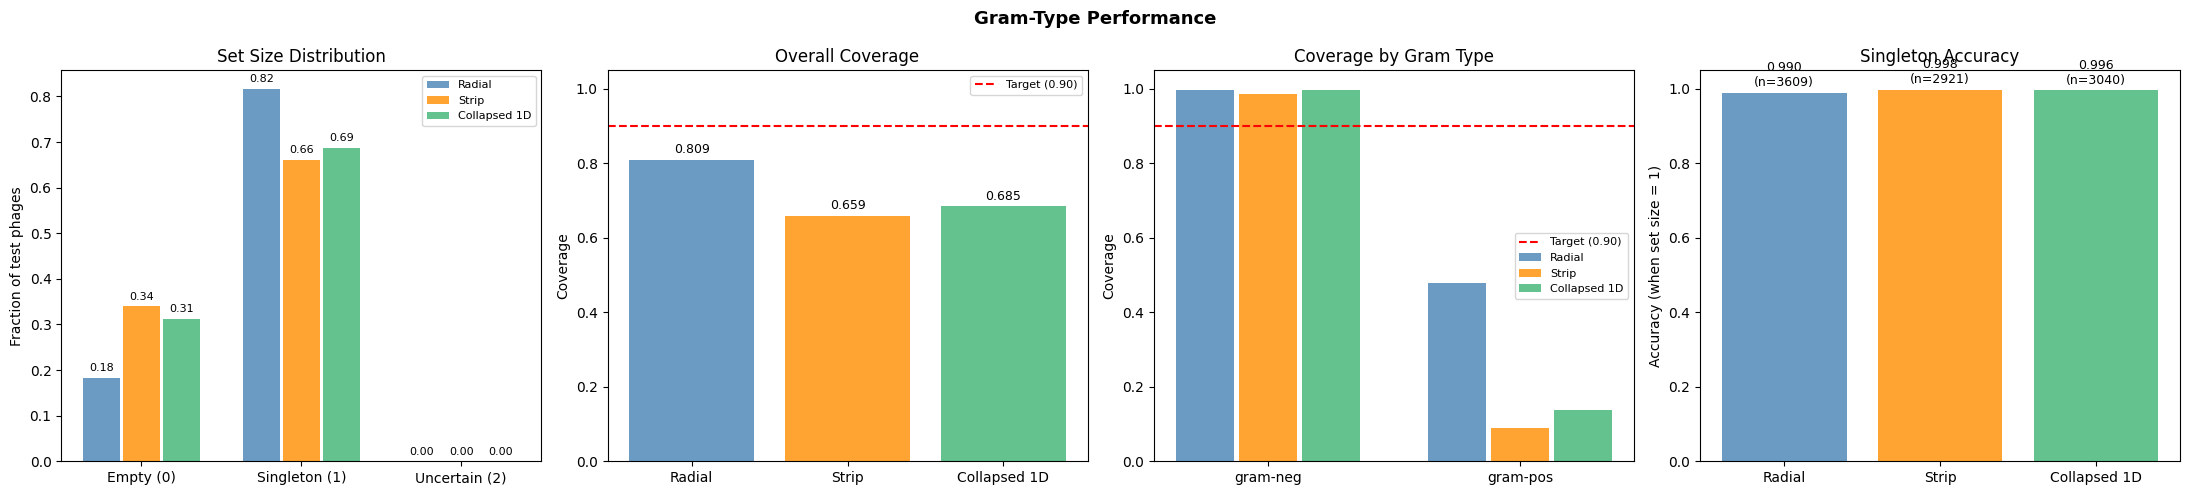

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]
offsets = [-0.25, 0.0, 0.25]

# Plot 1: Set size distribution
ax = axes[0]
x = np.array([0, 1, 2])
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    m = test_metrics[key]
    n_total = len(m["set_sizes"])
    fracs = [
        sum(1 for sz in m["set_sizes"] if sz == s) / n_total
        for s in [0, 1, 2]
    ]
    bars = ax.bar(x + offset, fracs, width=0.23, label=name, color=c, alpha=0.8)
    for rect, val in zip(bars, fracs):
        ax.text(rect.get_x() + rect.get_width()/2, val + 0.01, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(["Empty (0)", "Singleton (1)", "Uncertain (2)"])
ax.set_title("Set Size Distribution")
ax.set_ylabel("Fraction of test phages")
ax.legend(fontsize=8)

# Plot 2: Overall coverage
ax = axes[1]
means = [test_metrics[k]["coverage"] for k in method_keys]
bars = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)

# Plot 3: Per-class coverage
ax = axes[2]
gram_types = ["gram-neg", "gram-pos"]
x = np.arange(len(gram_types))
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    m = test_metrics[key]
    rates = [m["per_type_coverage"][gt] for gt in gram_types]
    ax.bar(x + offset, rates, width=0.23, label=name, color=c, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(gram_types)
ax.set_ylim(0, 1.05)
ax.set_title("Coverage by Gram Type")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)

# Plot 4: Singleton accuracy
ax = axes[3]
accuracies = [test_metrics[k]["singleton_accuracy"] if test_metrics[k]["singleton_accuracy"] is not None else 0 for k in method_keys]
ns = [int(test_metrics[k]["singleton_rate"] * len(test_metrics[k]["set_sizes"])) for k in method_keys]
bars = ax.bar(methods_names, accuracies, color=colors, alpha=0.8)
ax.set_ylim(0, 1.05)
ax.set_title("Singleton Accuracy")
ax.set_ylabel("Accuracy (when set size = 1)")
for bar, val, n_s in zip(bars, accuracies, ns):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}\n(n={n_s})",
            ha="center", va="bottom", fontsize=9)

plt.suptitle("Gram-Type Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Distribution of mean raw scores per phage (Test Fold 0):
  Overall: mean=0.269, std=0.271
  Min=0.024, Max=0.791

  Phages with mean score in (0.3, 0.7): 1402 / 4422

  gram-neg: mean=0.068, std=0.034
    Phages with score in (0.3, 0.7): 5 / 2811

  gram-pos: mean=0.619, std=0.081
    Phages with score in (0.3, 0.7): 1397 / 1611


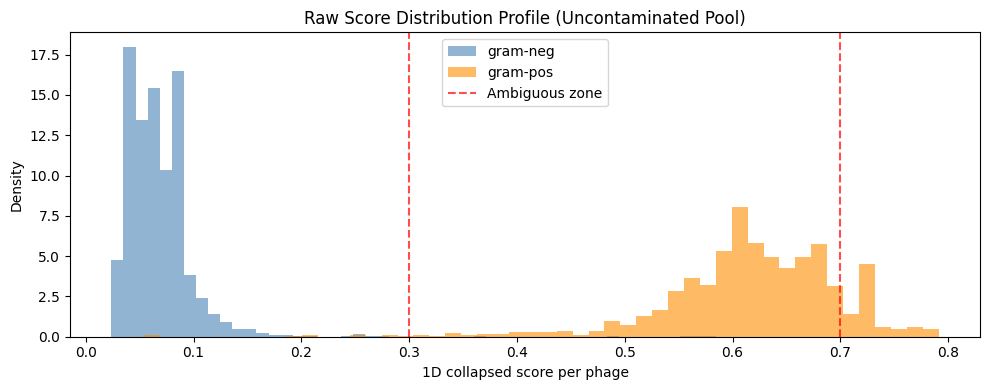

In [24]:
print("\n" + "="*55)
print("Distribution of mean raw scores per phage (Test Fold 0):")
print("="*55)
mean_scores = test_df[valid_cols].mean(axis=1)
print(f"  Overall: mean={mean_scores.mean():.3f}, std={mean_scores.std():.3f}")
print(f"  Min={mean_scores.min():.3f}, Max={mean_scores.max():.3f}")

near_half = ((mean_scores > 0.3) & (mean_scores < 0.7)).sum()
print(f"\n  Phages with mean score in (0.3, 0.7): {near_half} / {len(mean_scores)}")

for gt in ["gram-neg", "gram-pos"]:
    mask = test_df["host_type"] == gt
    scores = mean_scores[mask]
    print(f"\n  {gt}: mean={scores.mean():.3f}, std={scores.std():.3f}")
    print(f"    Phages with score in (0.3, 0.7): {((scores > 0.3) & (scores < 0.7)).sum()} / {len(scores)}")

plt.figure(figsize=(10, 4))
for gt, col in [("gram-neg", "steelblue"), ("gram-pos", "darkorange")]:
    mask = test_df["host_type"] == gt
    plt.hist(mean_scores[mask], bins=50, alpha=0.6, color=col, label=gt, density=True)
plt.axvline(0.3, color="red", linestyle="--", alpha=0.7, label="Ambiguous zone")
plt.axvline(0.7, color="red", linestyle="--", alpha=0.7)
plt.xlabel("1D collapsed score per phage")
plt.ylabel("Density")
plt.title("Raw Score Distribution Profile (Uncontaminated Pool)")
plt.legend()
plt.tight_layout()
plt.show()